## 1. Setup

In [1]:
#imports
import os
import ast
import json
import numpy as np
import pandas as pd

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#paths - central config, mirrors config.py conventions from the earlier pipeline

# inputs
W2V_CSV_PATH   = "/Users/prabinrimal/Desktop/New>>>>>/ANOTHER/cleaned_word2vec.csv"
SBERT_CSV_PATH = "/Users/prabinrimal/Desktop/New>>>>>/ANOTHER/light_cleaned_SBERT.csv"

# where to save/load models + vectors
MODEL_DIR   = "/Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_models"
VECTOR_DIR  = "/Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_vectors"

WORD2VEC_MODEL_PATH = os.path.join(MODEL_DIR, "word2vec.model")

W2V_VECTORS_PATH   = os.path.join(VECTOR_DIR, "resume_vectors_w2v.npy")
W2V_METADATA_PATH  = os.path.join(VECTOR_DIR, "resume_metadata_w2v.json")

SBERT_VECTORS_PATH  = os.path.join(VECTOR_DIR, "resume_vectors_sbert.npy")
SBERT_METADATA_PATH = os.path.join(VECTOR_DIR, "resume_metadata_sbert.json")

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VECTOR_DIR, exist_ok=True)

PREVIEW_LENGTH = 200  # chars shown in resume_preview for ranking output


## 2. Load preprocessed datasets


In [3]:
#load word2vec dataset
w2v_df = pd.read_csv(W2V_CSV_PATH)

#parse stringified token lists back into real python lists
w2v_df["tokens"] = w2v_df["resume_text"].apply(ast.literal_eval)

print("Word2Vec dataset:", w2v_df.shape)
w2v_df.head(2)


Word2Vec dataset: (1429, 4)


,resume_id,resume_text,category,tokens
0,0,"['experience', 'speech', 'process', 'deepfake'...",AI ML,"[experience, speech, process, deepfake, detect..."
1,1,"['education', 'phd', 'computer', 'science', 'g...",AI ML,"[education, phd, computer, science, georgia, i..."


In [4]:
#load SBERT dataset
sbert_df = pd.read_csv(SBERT_CSV_PATH)

print("SBERT dataset:", sbert_df.shape)
sbert_df.head(2)


SBERT dataset: (1429, 3)


,resume_id,resume_text,category
0,0,"experience in speech processing, deepfake dete...",AI ML
1,1,"Education PhD Computer Science, Georgia Instit...",AI ML


In [5]:
#sanity checks - both datasets should describe the same resumes
assert w2v_df["resume_id"].is_unique, "Duplicate resume_id in Word2Vec dataset"
assert sbert_df["resume_id"].is_unique, "Duplicate resume_id in SBERT dataset"
assert set(w2v_df["resume_id"]) == set(sbert_df["resume_id"]), "resume_id sets differ between datasets"
assert w2v_df["tokens"].apply(len).min() > 0, "Found an empty token list"

print("All checks passed.")


All checks passed.


## 3. Word2Vec

In [6]:
#train Word2Vec model
w2v_model = Word2Vec(
    sentences=w2v_df["tokens"].tolist(),
    vector_size=150,     
    window=8,
    min_count=2,       
    workers=4,
    sg=1,
    negative=15,     
    epochs=30,
    sample=1e-4,
)
w2v_model.save(WORD2VEC_MODEL_PATH)
print(f"Trained new Word2Vec model and saved to {WORD2VEC_MODEL_PATH}")

print("Vocabulary size:", len(w2v_model.wv))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Trained new Word2Vec model and saved to /Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_models/word2vec.model
Vocabulary size: 15604


In [7]:
####document vector = mean of its in-vocabulary word vectors
def get_doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

w2v_df["vector"] = w2v_df["tokens"].apply(lambda toks: get_doc_vector(toks, w2v_model))

#flag resumes where no tokens were in vocabulary (all-zero vector) - these will rank poorly/randomly
zero_vec_mask = w2v_df["vector"].apply(lambda v: np.allclose(v, 0))
print(f"{zero_vec_mask.sum()} resumes produced an all-zero vector (no in-vocab tokens)")
###########



0 resumes produced an all-zero vector (no in-vocab tokens)


In [8]:
#stack into a single matrix, aligned row-for-row with metadata
w2v_matrix = np.vstack(w2v_df["vector"].values)

w2v_metadata = w2v_df[["resume_id", "category", "resume_text"]].rename(
    columns={"resume_text": "tokens_str"}
).to_dict(orient="records")

#save vectors + metadata separately
np.save(W2V_VECTORS_PATH, w2v_matrix)
with open(W2V_METADATA_PATH, "w") as f:
    json.dump(w2v_metadata, f)

print(f"Saved {w2v_matrix.shape[0]} vectors (dim={w2v_matrix.shape[1]}) to {W2V_VECTORS_PATH}")
print(f"Saved metadata to {W2V_METADATA_PATH}")


Saved 1429 vectors (dim=150) to /Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_vectors/resume_vectors_w2v.npy
Saved metadata to /Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_vectors/resume_metadata_w2v.json


## 4. SBERT: encode resumes

In [9]:
#load SBERT model
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

# model's actual max sequence length (in wordpiece tokens), used for reference/logging
print("Model max_seq_length:", sbert_model.max_seq_length)


Model max_seq_length: 256


In [10]:
#sliding-window chunking so long resumes aren't silently truncated at 256 tokens
CHUNK_SIZE = 200   # words per chunk (conservative vs. the 256 wordpiece-token limit)
CHUNK_STRIDE = 150 # overlap of 50 words between consecutive chunks


def chunk_text(text, chunk_size=CHUNK_SIZE, stride=CHUNK_STRIDE):
    """Split text into overlapping word-level chunks. Always returns >=1 chunk."""
    words = text.split()
    if len(words) <= chunk_size:
        return [text]

    chunks = []
    start = 0
    while start < len(words):
        chunk = words[start:start + chunk_size]
        chunks.append(" ".join(chunk))
        if start + chunk_size >= len(words):
            break
        start += stride
    return chunks


def encode_resume_with_chunking(text, model):
    
    chunks = chunk_text(text)
    chunk_vectors = model.encode(
        chunks,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    doc_vector = chunk_vectors.mean(axis=0)
    norm = np.linalg.norm(doc_vector)
    if norm > 0:
        doc_vector = doc_vector / norm
    return doc_vector


In [11]:
#encode all resumes with chunking - batched at the resume level, chunked internally
from tqdm import tqdm

sbert_texts = sbert_df["resume_text"].tolist()

sbert_vectors = []
chunk_counts = []
for text in tqdm(sbert_texts, desc="Encoding resumes (chunked)"):
    n_chunks = len(chunk_text(text))
    chunk_counts.append(n_chunks)
    sbert_vectors.append(encode_resume_with_chunking(text, sbert_model))

sbert_matrix = np.vstack(sbert_vectors)

print("SBERT matrix shape:", sbert_matrix.shape)
print(f"Chunks per resume - min: {min(chunk_counts)}, max: {max(chunk_counts)}, "
      f"mean: {np.mean(chunk_counts):.1f}")
print(f"Resumes needing >1 chunk: {sum(c > 1 for c in chunk_counts)} / {len(chunk_counts)}")


Encoding resumes (chunked):   0%|          | 0/1429 [00:00<?, ?it/s]

Encoding resumes (chunked): 100%|██████████| 1429/1429 [01:12<00:00, 19.66it/s]

SBERT matrix shape: (1429, 384)
Chunks per resume - min: 1, max: 25, mean: 4.3
Resumes needing >1 chunk: 1314 / 1429


In [12]:
#save vectors + metadata
sbert_metadata = sbert_df[["resume_id", "category", "resume_text"]].to_dict(orient="records")

np.save(SBERT_VECTORS_PATH, sbert_matrix)
with open(SBERT_METADATA_PATH, "w") as f:
    json.dump(sbert_metadata, f)

print(f"Saved {sbert_matrix.shape[0]} vectors (dim={sbert_matrix.shape[1]}) to {SBERT_VECTORS_PATH}")
print(f"Saved metadata to {SBERT_METADATA_PATH}")


Saved 1429 vectors (dim=384) to /Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_vectors/resume_vectors_sbert.npy
Saved metadata to /Users/prabinrimal/Desktop/New>>>>>/roughhhhhh/test_vectors/resume_metadata_sbert.json


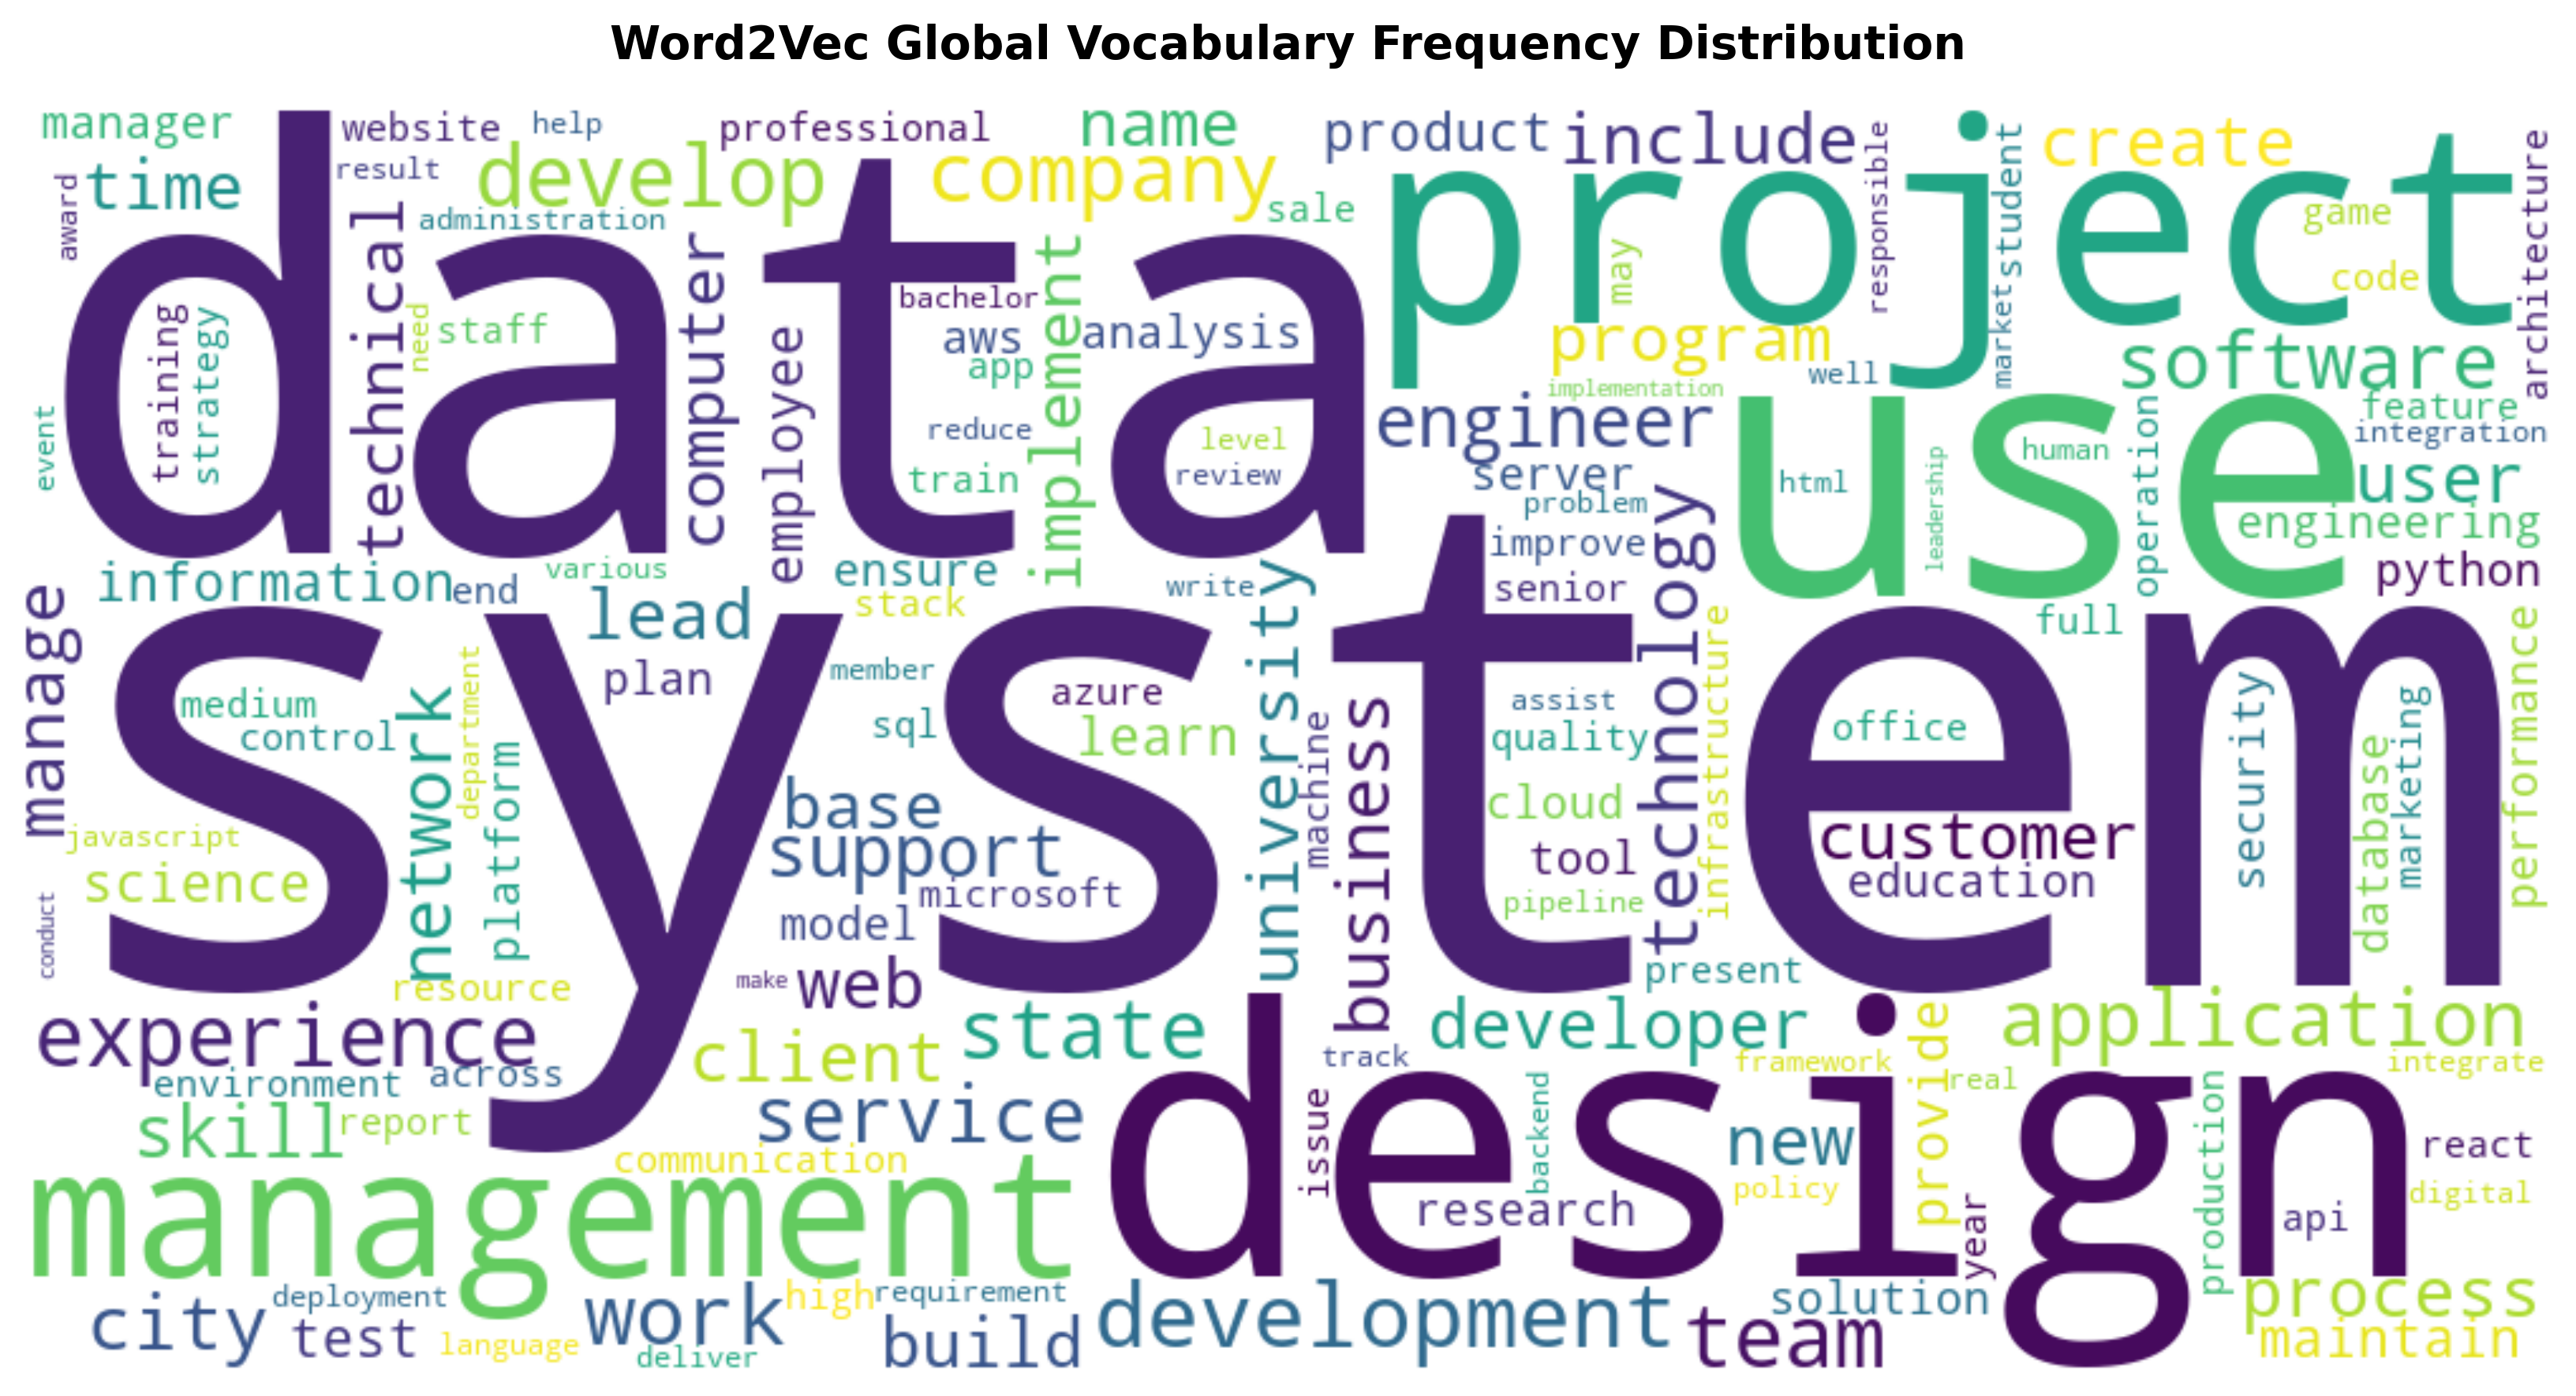

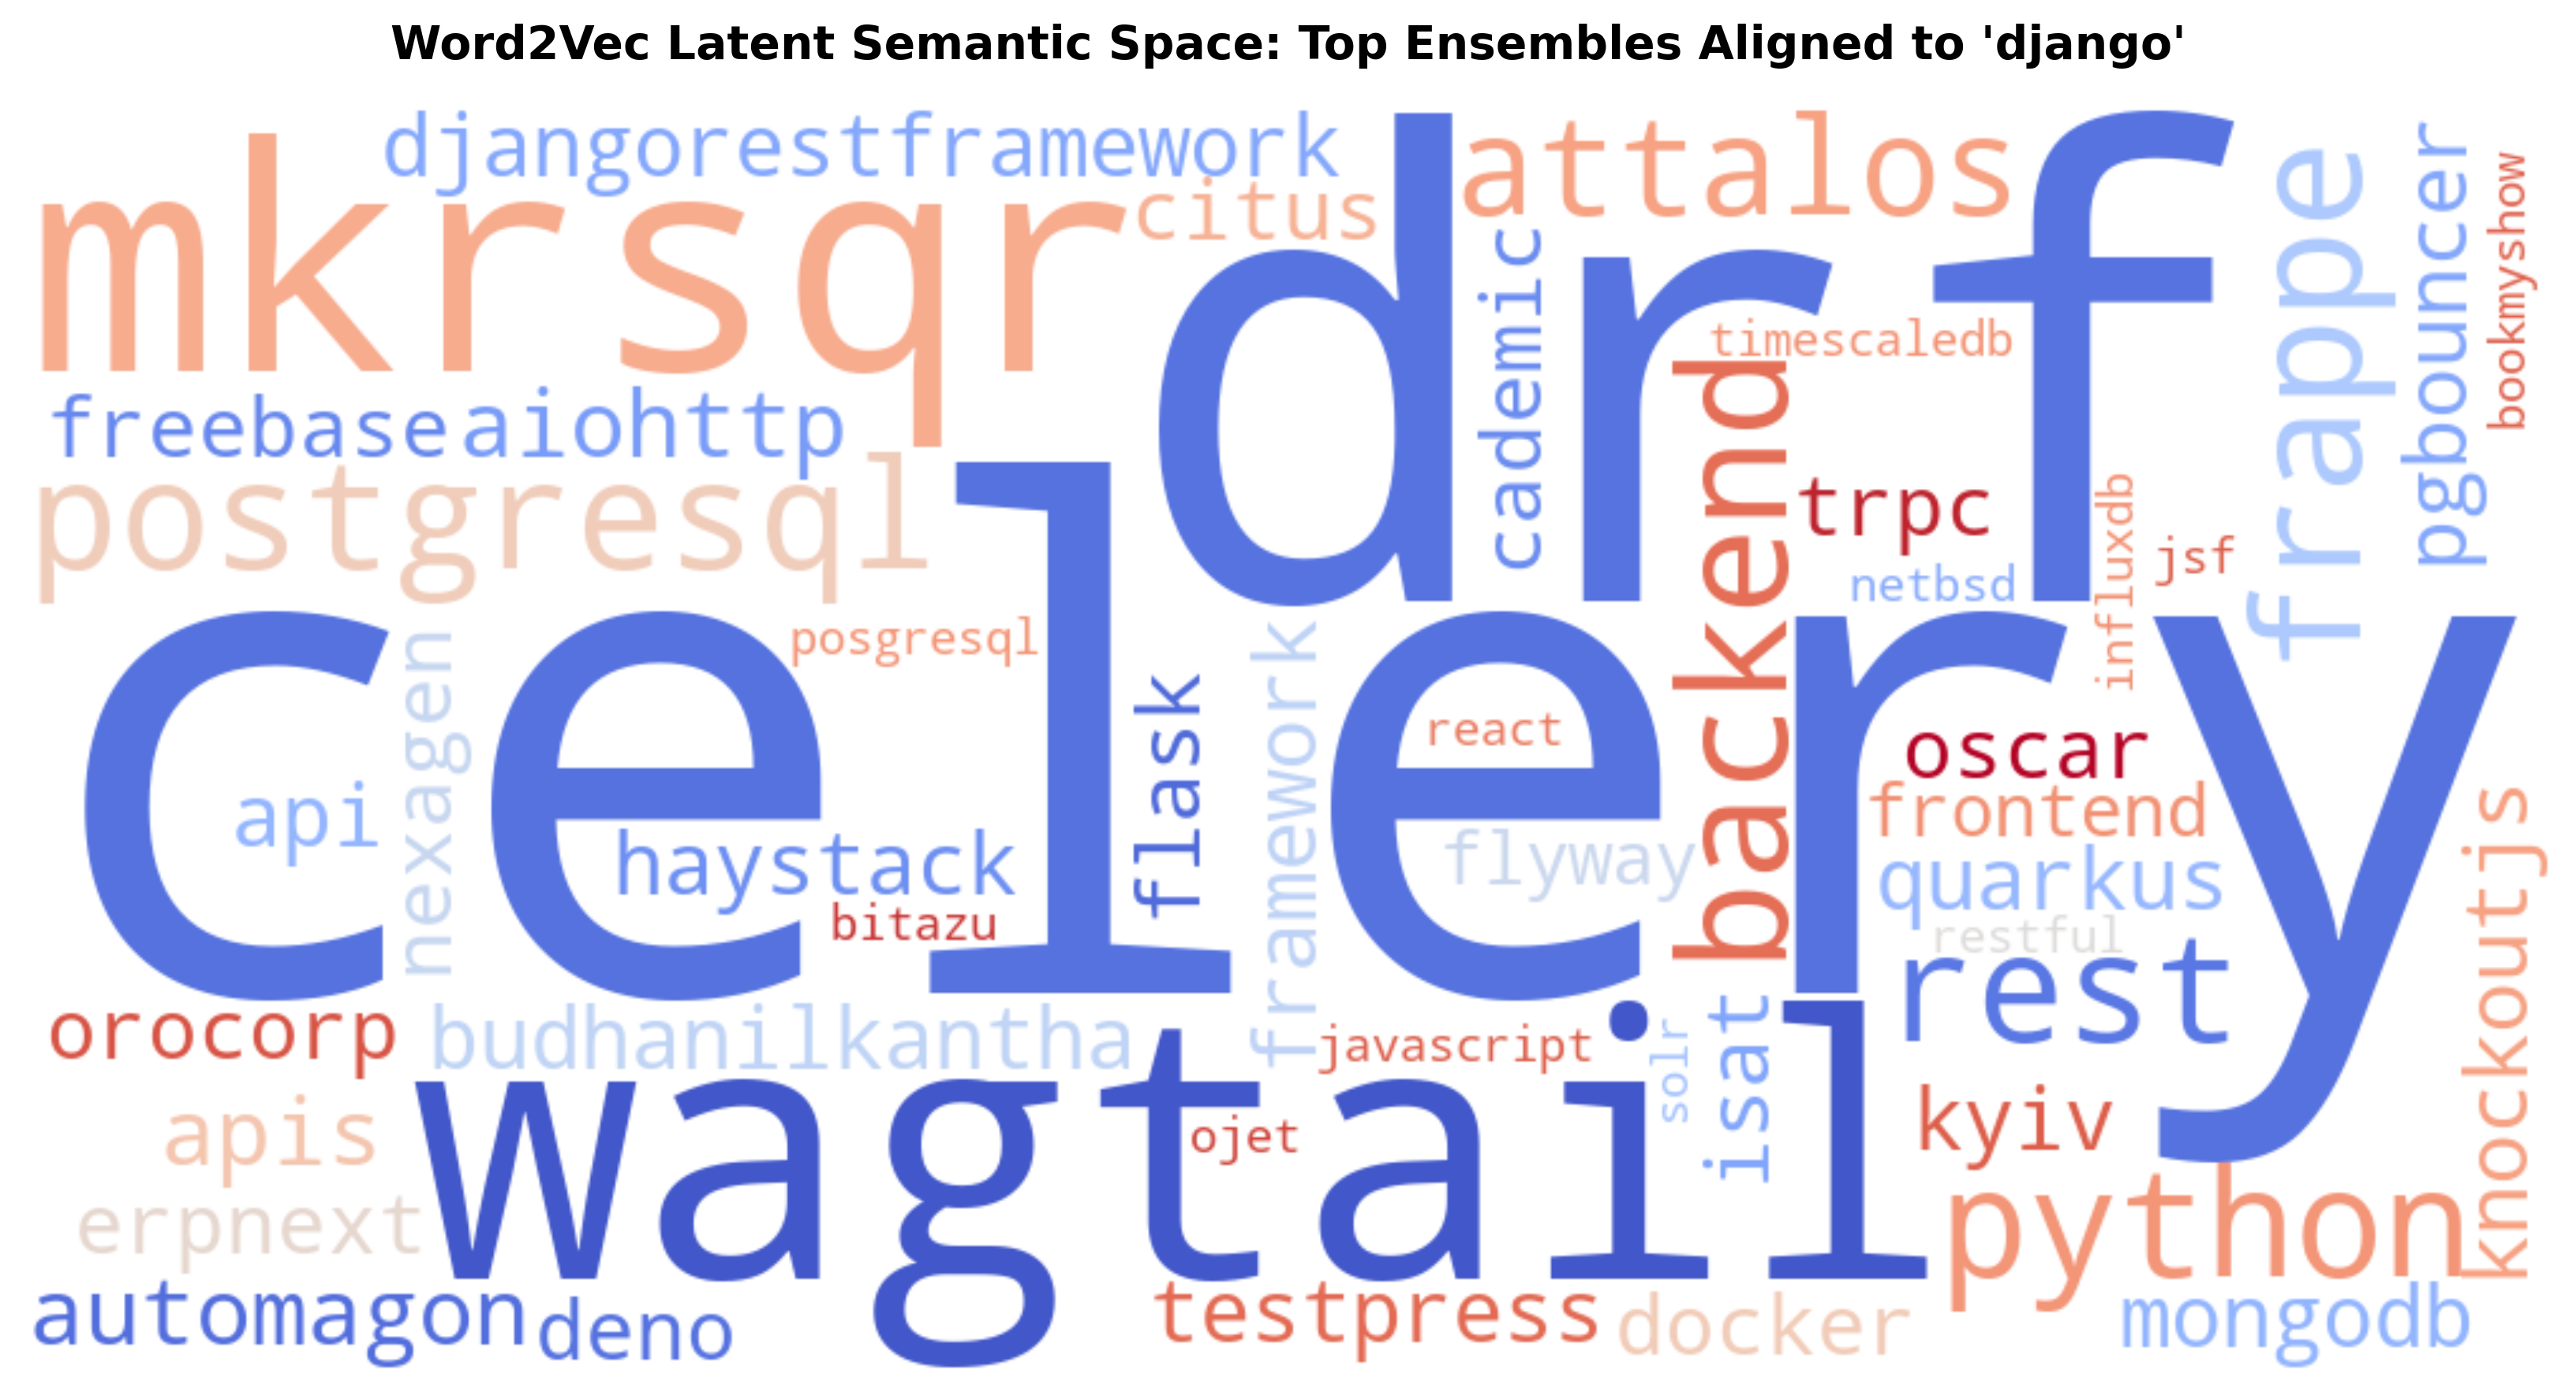

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Ensure your model is trained and active (w2v_model)

# ==============================================================================
# APPROACH 1: Global Vocabulary Frequency Word Cloud
# ==============================================================================
try:
    # Modern Gensim (4.x+) syntax to extract true vocabulary frequency counts
    word_freqs = {word: w2v_model.wv.get_vecattr(word, "count") for word in w2v_model.wv.index_to_key}
except AttributeError:
    # Legacy Gensim (3.x) fallback syntax
    word_freqs = {word: vocab_obj.count for word, vocab_obj in w2v_model.wv.vocab.items()}

# Generate the global word cloud
global_wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    max_words=150,
    colormap='viridis', # Professional corporate palette
    random_state=42
).generate_from_frequencies(word_freqs)

# Plot Global Word Cloud
plt.figure(figsize=(12, 6), dpi=300)
plt.imshow(global_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word2Vec Global Vocabulary Frequency Distribution", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# ==============================================================================
# APPROACH 2: Semantic Similarity Word Cloud (Highly Recommended for Defense)
# ==============================================================================
# We pick a core domain anchor term present in your dataset vocabulary
target_term = "django" 

if target_term in w2v_model.wv:
    # Retrieve the top 100 most similar words and their cosine similarity weights
    similar_words = w2v_model.wv.most_similar(target_term, topn=100)
    similarity_dict = {word: weight for word, weight in similar_words}
    
    # Generate the semantic word cloud
    semantic_wordcloud = WordCloud(
        width=1000, 
        height=500, 
        background_color='white',
        max_words=50,
        colormap='coolwarm', # Distinct look separating it from the global map
        random_state=42
    ).generate_from_frequencies(similarity_dict)

    # Plot Semantic Word Cloud
    plt.figure(figsize=(12, 6), dpi=300)
    plt.imshow(semantic_wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word2Vec Latent Semantic Space: Top Ensembles Aligned to '{target_term}'", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print(f"Target term '{target_term}' not found in Word2Vec vocabulary.")